In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#import instacart.csv/par

df_instacart = pd.read_parquet("../data/processed/instacart.parquet")
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [3]:
df_instacart.shape

(1384706, 22)

In [4]:
df_instacart.describe()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,prices,Age,n_dependants,income
count,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384618e+06,1.384706e+06,1.384706e+06,1.384706e+06
mean,1.706298e+06,1.709135e+01,2.701394e+00,1.357761e+01,1.706626e+01,8.758180e+00,5.985964e-01,1.411711e+01,4.938182e+01,1.498778e+00,9.766228e+04
std,9.897342e+05,1.661400e+01,2.167637e+00,4.238461e+00,1.042639e+01,7.423973e+00,4.901825e-01,6.802253e+02,1.843685e+01,1.117567e+00,4.199139e+04
min,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.800000e+01,0.000000e+00,2.591100e+04
25%,8.433700e+05,6.000000e+00,1.000000e+00,1.000000e+01,7.000000e+00,3.000000e+00,0.000000e+00,4.300000e+00,3.300000e+01,0.000000e+00,6.485900e+04
50%,1.701880e+06,1.100000e+01,3.000000e+00,1.400000e+01,1.500000e+01,7.000000e+00,1.000000e+00,7.400000e+00,4.900000e+01,1.000000e+00,9.576500e+04
75%,2.568023e+06,2.100000e+01,5.000000e+00,1.700000e+01,3.000000e+01,1.200000e+01,1.000000e+00,1.130000e+01,6.500000e+01,2.000000e+00,1.268178e+05
max,3.421070e+06,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,8.000000e+01,1.000000e+00,9.999900e+04,8.100000e+01,3.000000e+00,5.910890e+05


In [5]:
# Data preparation
orders_by_dow = (df_instacart[['order_id', 'order_dow']]
                 .drop_duplicates()
                 .groupby('order_dow')
                 .size()
                 )
type(orders_by_dow)


pandas.Series

In [6]:
d = pd.DataFrame(orders_by_dow).reset_index()
d

,order_dow,0
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959
5,5,17406
6,6,18901


In [7]:
d.columns

Index(['order_dow', 0], dtype='object')

In [8]:
d.rename(columns={0:'number_of_orders'},inplace=True)
d

,order_dow,number_of_orders
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959
5,5,17406
6,6,18901


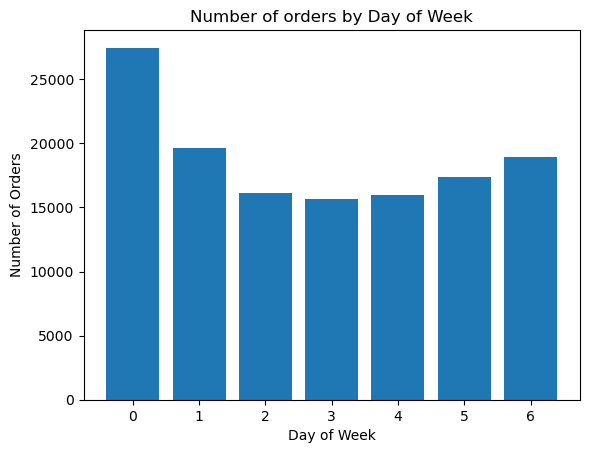

In [9]:
plt.Figure()
plt.bar(orders_by_dow.index,orders_by_dow.values)
plt.title('Number of orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.show()

In [10]:
df_instacart.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division'],
      dtype='str')

In [11]:
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby(["order_dow"])
    .size()
)

orders_by_day

order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

In [12]:
df = orders_by_day.reset_index()

In [13]:
df.rename(columns={0:'number_of_orders'},inplace=True)
df.head()

,order_dow,number_of_orders
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959


In [16]:
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

orders_by_hour.head()

order_hour_of_day
0    852
1    507
2    305
3    223
4    218
dtype: int64

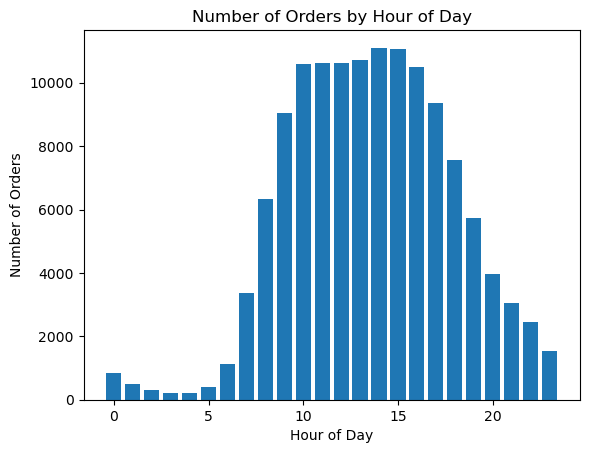

In [17]:
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

plt.figure()
plt.bar(orders_by_hour.index, orders_by_hour.values)
plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

In [18]:
top_departments = df_instacart["department"].value_counts().head(10)
top_departments

department
produce            409087
dairy eggs         217051
snacks             118862
beverages          113962
frozen             100426
pantry              81242
bakery              48394
canned goods        46799
deli                44291
dry goods pasta     38713
Name: count, dtype: int64

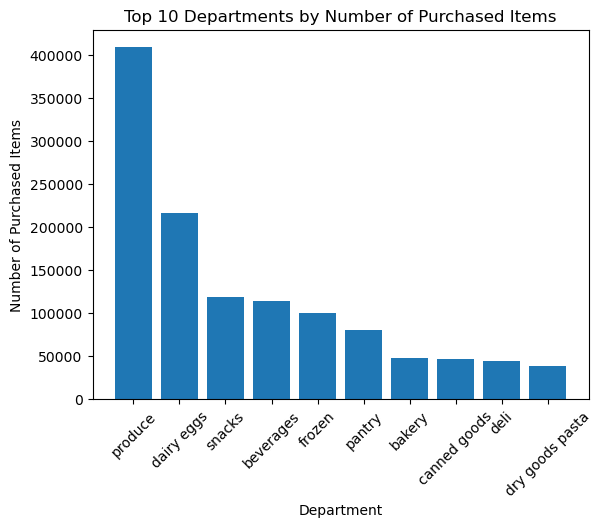

In [19]:
top_departments = df_instacart["department"].value_counts().head(10)

plt.figure()
plt.bar(top_departments.index, top_departments.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Department")
plt.ylabel("Number of Purchased Items")
plt.xticks(rotation=45)
plt.show()

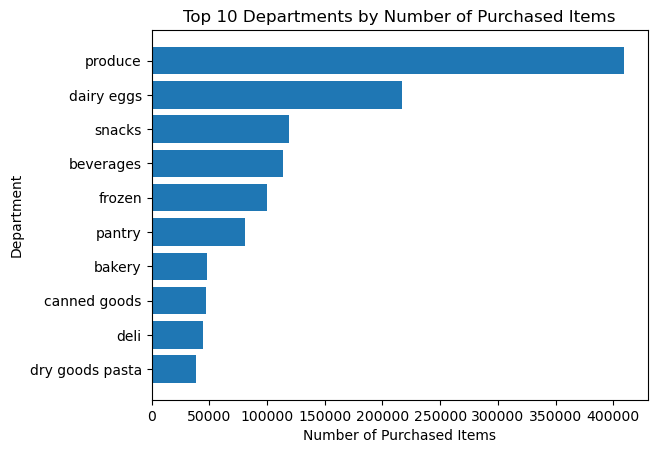

In [20]:
top_departments_sorted = df_instacart["department"].value_counts().head(10).sort_values()

plt.figure()
plt.barh(top_departments_sorted.index, top_departments_sorted.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Number of Purchased Items")
plt.ylabel("Department")
plt.show()

In [21]:
df_instacart["prices"].describe()

count    1.384618e+06
mean     1.411711e+01
std      6.802253e+02
min      1.000000e+00
25%      4.300000e+00
50%      7.400000e+00
75%      1.130000e+01
max      9.999900e+04
Name: prices, dtype: float64

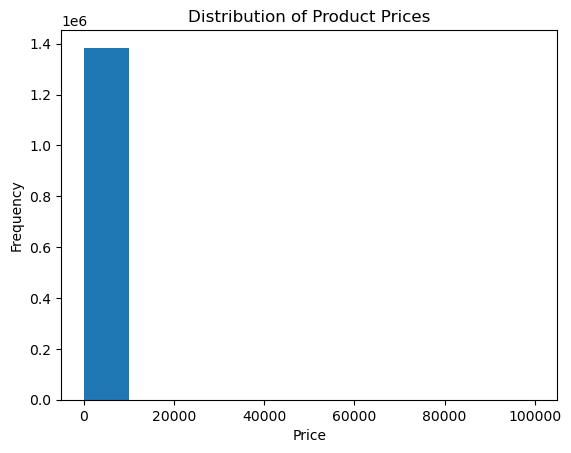

In [22]:
plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=10)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [24]:
upper_limit = df_instacart["prices"].quantile(0.99)
upper_limit

np.float64(18.1)

In [25]:
df_prices_q = df_instacart[df_instacart["prices"] <= upper_limit]
df_prices_q["prices"].describe()

count    1.370887e+06
mean     7.668451e+00
std      4.039330e+00
min      1.000000e+00
25%      4.200000e+00
50%      7.300000e+00
75%      1.120000e+01
max      1.810000e+01
Name: prices, dtype: float64

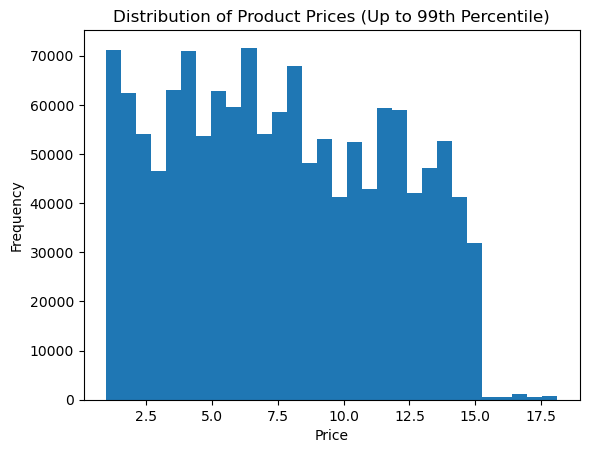

In [26]:
plt.figure()
plt.hist(df_prices_q["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Up to 99th Percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [27]:
upper_limit_95 = df_instacart["prices"].quantile(0.95)
upper_limit_95

np.float64(14.3)

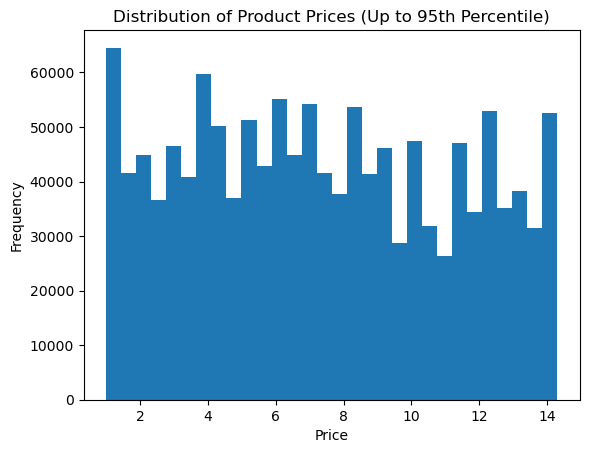

In [29]:
plt.figure()
plt.hist(df_prices_q95["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Up to 95th Percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=30)
plt.xlim(0, 50)
plt.title("Distribution of Product Prices (Zoomed X-Axis)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [31]:
summary_stas = df_instacart.describe()

In [38]:
df_instacart['reordered'].value_counts()

reordered
1    828880
0    555826
Name: count, dtype: int64

In [32]:
summary_stas

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,prices,Age,n_dependants,income
count,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384618e+06,1.384706e+06,1.384706e+06,1.384706e+06
mean,1.706298e+06,1.709135e+01,2.701394e+00,1.357761e+01,1.706626e+01,8.758180e+00,5.985964e-01,1.411711e+01,4.938182e+01,1.498778e+00,9.766228e+04
std,9.897342e+05,1.661400e+01,2.167637e+00,4.238461e+00,1.042639e+01,7.423973e+00,4.901825e-01,6.802253e+02,1.843685e+01,1.117567e+00,4.199139e+04
min,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.800000e+01,0.000000e+00,2.591100e+04
25%,8.433700e+05,6.000000e+00,1.000000e+00,1.000000e+01,7.000000e+00,3.000000e+00,0.000000e+00,4.300000e+00,3.300000e+01,0.000000e+00,6.485900e+04
50%,1.701880e+06,1.100000e+01,3.000000e+00,1.400000e+01,1.500000e+01,7.000000e+00,1.000000e+00,7.400000e+00,4.900000e+01,1.000000e+00,9.576500e+04
75%,2.568023e+06,2.100000e+01,5.000000e+00,1.700000e+01,3.000000e+01,1.200000e+01,1.000000e+00,1.130000e+01,6.500000e+01,2.000000e+00,1.268178e+05
max,3.421070e+06,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,8.000000e+01,1.000000e+00,9.999900e+04,8.100000e+01,3.000000e+00,5.910890e+05


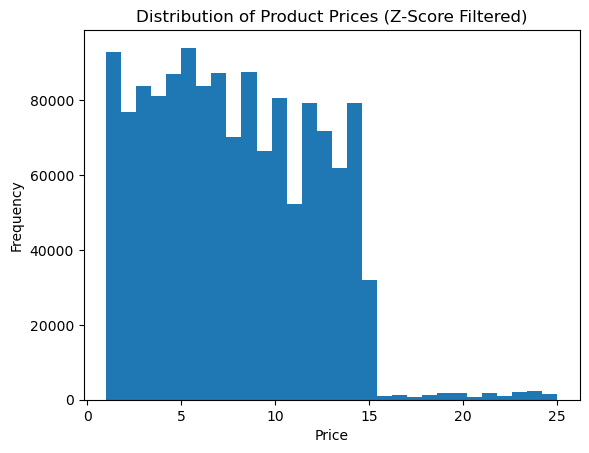

In [33]:
mean_price = df_instacart["prices"].mean()
std_price = df_instacart["prices"].std()

z_scores = (df_instacart["prices"] - mean_price) / std_price

df_prices_z = df_instacart[z_scores.abs() < 3]

plt.figure()
plt.hist(df_prices_z["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Z-Score Filtered)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [34]:
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

avg_price_by_department

department
snacks              4.272277
other               7.184457
dry goods pasta     7.388252
household           7.402065
canned goods        7.530263
beverages           7.660526
babies              7.682672
deli                7.768707
international       7.799126
frozen              7.801781
bakery              7.833023
pets                7.867823
pantry              7.955316
personal care       7.989259
produce             7.997862
breakfast           8.090261
alcohol             8.126044
bulk                8.211626
missing             8.599139
meat seafood       16.202349
dairy eggs         48.606962
Name: prices, dtype: float64

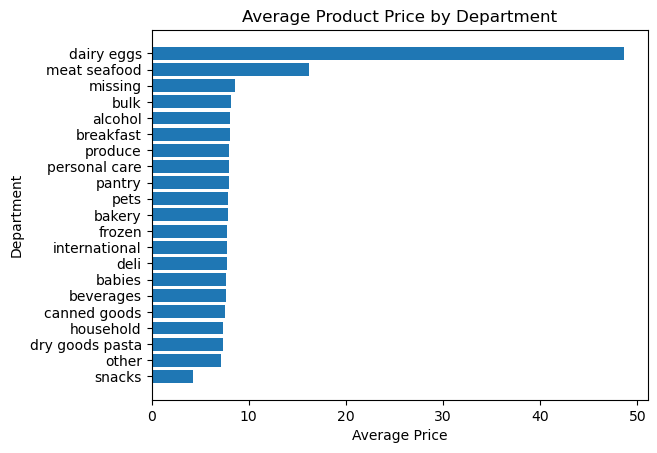

In [35]:
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure()
plt.barh(avg_price_by_department.index, avg_price_by_department.values)
plt.title("Average Product Price by Department")
plt.xlabel("Average Price")
plt.ylabel("Department")
plt.show()

In [36]:
reorder_rate_by_region = (
    df_instacart
    .groupby("region")["reordered"]
    .mean()
    .sort_values(ascending=True)
)

reorder_rate_by_region

region
South        0.596392
Midwest      0.598615
West         0.599062
Northeast    0.602097
Name: reordered, dtype: float64

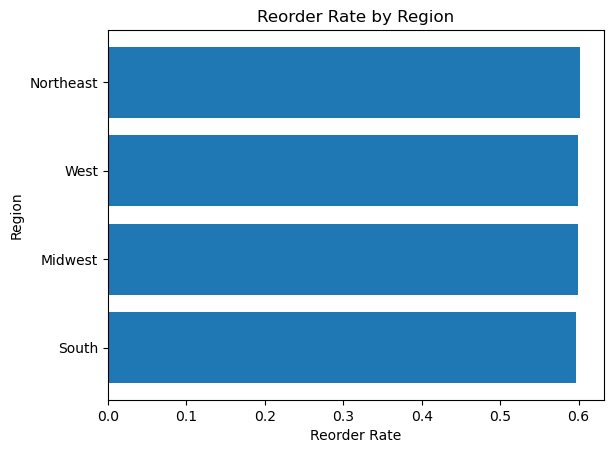

In [37]:
reorder_rate_by_region = (
    df_instacart
    .groupby("region")["reordered"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure()
plt.barh(reorder_rate_by_region.index, reorder_rate_by_region.values)
plt.title("Reorder Rate by Region")
plt.xlabel("Reorder Rate")
plt.ylabel("Region")
plt.show()

In [39]:
customer_profile = df_instacart[
    ["First Name", "Surname", "Age", "income"]
].drop_duplicates()

customer_profile.head()

,First Name,Surname,Age,income
0,Linda,Nguyen,31,40423
11,Norma,Chapman,68,64940
42,Janet,Lester,75,115242
51,Peter,Villegas,39,89095
60,Anna,Allison,32,88603


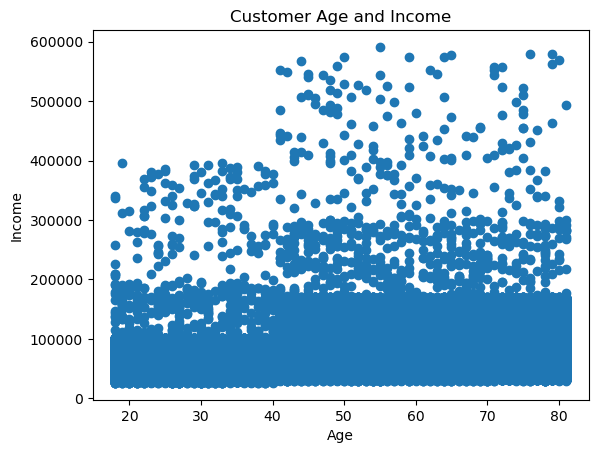

In [40]:
customer_profile = df_instacart[
    ["First Name", "Surname", "Age", "income"]
].drop_duplicates()

plt.figure()
plt.scatter(customer_profile["Age"], customer_profile["income"])
plt.title("Customer Age and Income")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

Session06

In [55]:
def full_name(first_name:str, last_name:str):
    """
    This returns full name 
    """
    #logic
    fn = first_name + " " + last_name
    return fn

In [50]:
full_name('a' , 'b')

'a b'

In [60]:
def age_segment(age:int):
    if age >=65 :
        return 'Senior'
    #else:
    return 'Young'

In [61]:
age_segment(30)

'Young'

In [70]:
def gross_salary(net_salary:int, tax:float = 0.2):
    """
    This return gross salary
    """
    gross = net_salary*(1+tax)
    return gross

In [71]:
gross_salary(1000)

1200.0

In [72]:
def score_label(score):
    if score >= 90:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 50:
        return "Pass"
    else:
        return "Fail"

score_label(85)

'Good'

In [73]:
import pandas as pd

df_scores = pd.DataFrame({
    "student": ["Anna", "Ben", "Chris", "Diana", "Eva"],
    "score": [95, 78, 61, 43, 88]
})

df_scores

,student,score
0,Anna,95
1,Ben,78
2,Chris,61
3,Diana,43
4,Eva,88


In [74]:
df_scores['mark'] = [score_label(i) for i in df_scores['score']]

In [75]:
df_scores

,student,score,mark
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


In [76]:
df_scores['mark_apply'] = df_scores['score'].apply(score_label)

In [77]:
df_scores.head()

,student,score,mark,mark_apply
0,Anna,95,Excellent,Excellent
1,Ben,78,Good,Good
2,Chris,61,Pass,Pass
3,Diana,43,Fail,Fail
4,Eva,88,Good,Good


In [87]:
def score_label(score, a=90, b=70, c=50):
    if score >= a:
        return "Excellent"
    elif score >= b:
        return "Good"
    elif score >= c:
        return "Pass"
    else:
        return "Fail"

In [89]:
score_label(score = 85, a = 95)

'Good'

In [85]:
def classify_price(price, low=5, high=15):
    if price <= low:
        return "Low-range product"
    elif price <= high:
        return "Mid-range product"
    else:
        return "High-range product"

classify_price(9)

'Mid-range product'

In [80]:
classify_price(9, low=3, high=10)

'Mid-range product'

In [90]:
df_products_dummy = pd.DataFrame({
    "product": ["Milk", "Bread", "Juice", "Cheese", "Steak", "Apples"],
    "price": [2.5, 1.8, 6.2, 12.0, 24.5, 4.2]
})

df_products_dummy

,product,price
0,Milk,2.5
1,Bread,1.8
2,Juice,6.2
3,Cheese,12.0
4,Steak,24.5
5,Apples,4.2


In [91]:
df_products_dummy["price_range"] = df_products_dummy["price"].apply(classify_price)
df_products_dummy

,product,price,price_range
0,Milk,2.5,Low-range product
1,Bread,1.8,Low-range product
2,Juice,6.2,Mid-range product
3,Cheese,12.0,Mid-range product
4,Steak,24.5,High-range product
5,Apples,4.2,Low-range product


Task 3

In [95]:
df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age": [22, 35, 47, 63, 29],
    "income": [18000, 42000, 72000, 95000, 25000]
})

df_customers_dummy

,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


Task 1

In [96]:
def age_group_label(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"

df_customers_dummy["age_group"] = df_customers_dummy["age"].apply(age_group_label)
df_customers_dummy

,customer,age,income,age_group
0,A,22,18000,Young
1,B,35,42000,Middle
2,C,47,72000,Middle
3,D,63,95000,Senior
4,E,29,25000,Young


Task 2

In [97]:
def income_band(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"

df_customers_dummy["income_group"] = df_customers_dummy["income"].apply(income_band)
df_customers_dummy

,customer,age,income,age_group,income_group
0,A,22,18000,Young,Low income
1,B,35,42000,Middle,Middle income
2,C,47,72000,Middle,High income
3,D,63,95000,Senior,High income
4,E,29,25000,Young,Low income
